In [1]:
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import wavfile

from iqwav.io import (
    load_wav,
    load_wav_iq,
    load_raw_iq,
)

from iqwav.modulation import generate_iq_tone

from iqwav.dsp import (
    magnitude_spectrum,
    periodogram_psd,
    welch_psd,
    spectrogram_data,
)

In [2]:
fs = 1000
freq = 125
duration = 1.0

t, iq = generate_iq_tone(
    fs=fs,
    freq=freq,
    duration=duration
)

print("Samples:", len(iq))
print("Sampling rate:", fs)
print("Frequency:", freq)

Samples: 1000
Sampling rate: 1000
Frequency: 125


In [3]:
## Create temporary raw and wav files

tmp = tempfile.TemporaryDirectory()
tmp_path = Path(tmp.name)

wav_path = tmp_path / "test_iq.wav"
raw_path = tmp_path / "test.iq"

# WAV: channel 0 = I, channel 1 = Q
stereo = np.column_stack((
    iq.real,
    iq.imag
)).astype(np.float32)

wavfile.write(
    wav_path,
    fs,
    stereo
)

# RAW IQ: I0 Q0 I1 Q1 ...
raw = np.empty(
    2 * len(iq),
    dtype=np.float32
)

raw[0::2] = iq.real
raw[1::2] = iq.imag

raw.tofile(raw_path)

print("WAV path:", wav_path)
print("RAW path:", raw_path)

WAV path: C:\Users\mhrit\AppData\Local\Temp\tmpah9ftlzn\test_iq.wav
RAW path: C:\Users\mhrit\AppData\Local\Temp\tmpah9ftlzn\test.iq


In [4]:
wav_fs, wav_samples = load_wav(wav_path)

print("Sampling rate:", wav_fs)
print("Shape:", wav_samples.shape)
print("Dtype:", wav_samples.dtype)

Sampling rate: 1000
Shape: (1000, 2)
Dtype: float32


In [5]:
wav_fs, wav_iq = load_wav_iq(wav_path)

print("Sampling rate:", wav_fs)
print("Samples:", len(wav_iq))
print("Dtype:", wav_iq.dtype)

print("\nFirst 5 IQ samples:")
print(wav_iq[:5])

Sampling rate: 1000
Samples: 1000
Dtype: complex128

First 5 IQ samples:
[ 1.00000000e+00+0.00000000e+00j  7.07106769e-01+7.07106769e-01j
  6.12323426e-17+1.00000000e+00j -7.07106769e-01+7.07106769e-01j
 -1.00000000e+00+1.22464685e-16j]


In [6]:
raw_iq = load_raw_iq(
    raw_path,
    dtype=np.float32,
    iq_order="IQ"
)

print("Samples:", len(raw_iq))
print("Dtype:", raw_iq.dtype)

print("\nFirst 5 IQ samples:")
print(raw_iq[:5])

Samples: 1000
Dtype: complex128

First 5 IQ samples:
[ 1.00000000e+00+0.00000000e+00j  7.07106769e-01+7.07106769e-01j
  6.12323426e-17+1.00000000e+00j -7.07106769e-01+7.07106769e-01j
 -1.00000000e+00+1.22464685e-16j]


In [7]:
print(
    "WAV and RAW same:",
    np.allclose(wav_iq, raw_iq)
)

print(
    "Loaded WAV close to original:",
    np.allclose(wav_iq, iq)
)

print(
    "Loaded RAW close to original:",
    np.allclose(raw_iq, iq)
)

WAV and RAW same: True
Loaded WAV close to original: True
Loaded RAW close to original: True


Expected frequency: 125
Detected FFT peak: 125.0


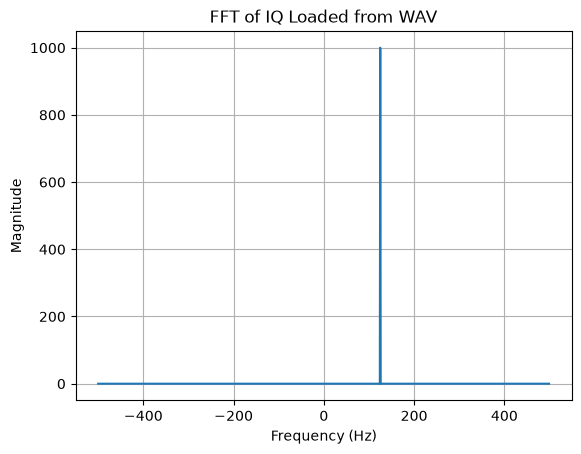

In [8]:
## FFT of loaded iq signal

freqs, magnitude = magnitude_spectrum(
    wav_iq,
    wav_fs
)

peak_freq = freqs[np.argmax(magnitude)]

print("Expected frequency:", freq)
print("Detected FFT peak:", peak_freq)

plt.plot(freqs, magnitude)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT of IQ Loaded from WAV")
plt.grid()

plt.show()

Expected frequency: 125
Detected FFT peak: 125.0


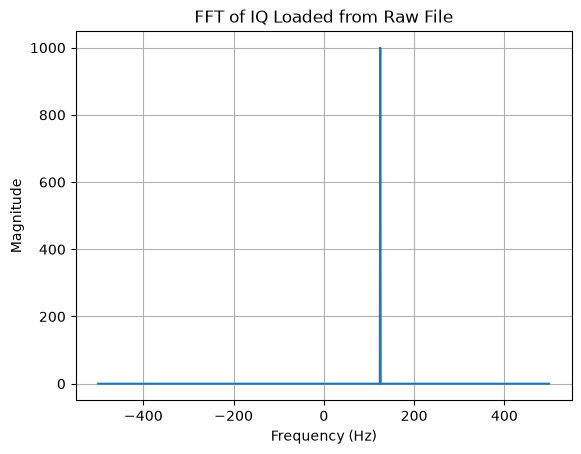

In [9]:
## FFT of raw iq file

freqs_raw, magnitude_raw = magnitude_spectrum(
    raw_iq,
    fs
)

peak_freq_raw = freqs_raw[
    np.argmax(magnitude_raw)
]

print("Expected frequency:", freq)
print("Detected FFT peak:", peak_freq_raw)

plt.plot(freqs_raw, magnitude_raw)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT of IQ Loaded from Raw File")
plt.grid()

plt.show()

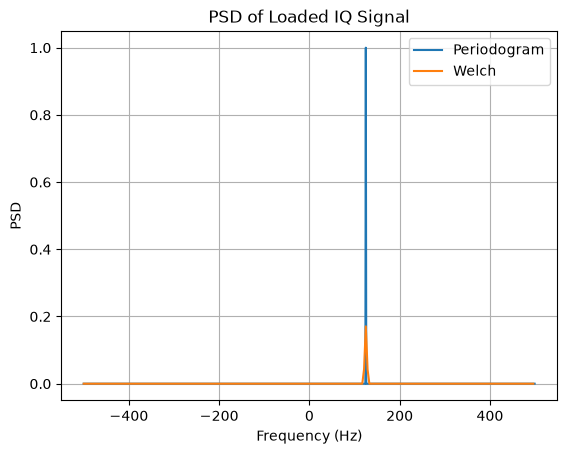

In [10]:
fp, psd_p = periodogram_psd(
    wav_iq,
    wav_fs
)

fw, psd_w = welch_psd(
    wav_iq,
    wav_fs
)

plt.plot(
    fp,
    psd_p,
    label="Periodogram"
)

plt.plot(
    fw,
    psd_w,
    label="Welch"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("PSD of Loaded IQ Signal")
plt.legend()
plt.grid()

plt.show()

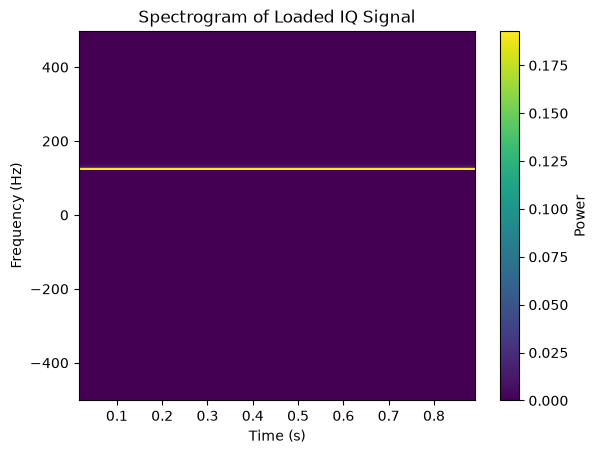

In [11]:
times, freqs_spec, power = spectrogram_data(
    wav_iq,
    wav_fs,
    nperseg=250
)

plt.pcolormesh(
    times,
    freqs_spec,
    power,
    shading="auto"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of Loaded IQ Signal")

plt.colorbar(label="Power")

plt.show()

In [12]:
print("WAV FFT peak:", peak_freq, "Hz")
print("RAW FFT peak:", peak_freq_raw, "Hz")

print(
    "WAV correct:",
    np.isclose(peak_freq, freq)
)

print(
    "RAW correct:",
    np.isclose(peak_freq_raw, freq)
)

print(
    "Same IQ after loading:",
    np.allclose(wav_iq, raw_iq)
)

WAV FFT peak: 125.0 Hz
RAW FFT peak: 125.0 Hz
WAV correct: True
RAW correct: True
Same IQ after loading: True
